# Feature Engineering
### Goal: Use past sales data + external information to predict future `unit_sales`

---

We have **4 datasets**:

| File | What it contains |
|---|---|
| `timeseries.csv` | Daily sales numbers — this is what we want to predict |
| `oil.csv` | Daily crude oil price — oil affects how much people spend |
| `holidays.csv` | Public holiday dates in Ecuador |
| `stores.csv` | Store locations (city and region) |

By the end of this notebook you will have:
1. Merged all four datasets into one table
2. Created new features the model can learn from

---
## Step 1 — Install & Import Libraries

In [73]:
# Run this cell first — it loads the tools we need

# pandas lets us work with tables (like Excel, but in Python)
import pandas as pd

# matplotlib lets us draw charts
import matplotlib.pyplot as plt

# os lets us build file paths that work on any computer
import os

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## Step 2 — Set the Data Folder

Change `DATA_DIR` below to match the folder where your CSV files are saved.

In [74]:
# Change this to the folder where your CSV files are saved
# Example on Windows: DATA_DIR = 'C:/Users/YourName/Downloads/data'
# Example on Mac:     DATA_DIR = '/Users/YourName/Downloads/data'
# If the CSV files are in a 'data' folder next to this notebook, leave it as is:

DATA_DIR = 'C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\\Data'

print("Looking for files in:", DATA_DIR)

Looking for files in: C:\Users\alipa\Documents\3- Academic\6- Data Science, phyton\1- class files\9- Time Series Modeling\Time-Series\Data


---
## Step 3 — Load the Data

We load each CSV file into a pandas **DataFrame** (a table with rows and columns).

In [75]:
# Load each CSV file into a separate table

# Sales data — one row per day
timeseries = pd.read_csv(os.path.join(DATA_DIR, 'timeseries.csv'))

# Oil price data — one row per day
oil = pd.read_csv(os.path.join(DATA_DIR, 'oil.csv'))

# Holiday dates
holidays = pd.read_csv(os.path.join(DATA_DIR, 'holidays.csv'))

# Store information (city, region)
stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))

print("Files loaded!")
print("Sales rows:", len(timeseries))
print("Oil rows:", len(oil))
print("Holiday rows:", len(holidays))
print("Store rows:", len(stores))

Files loaded!
Sales rows: 452
Oil rows: 1218
Holiday rows: 350
Store rows: 54


---
## Step 4 — Explore the Data

Always look at your data before doing anything with it.  
`.head()` shows the first 5 rows of a table.

In [76]:
# Look at the first 5 rows of the sales table
print("=== Sales data (timeseries) ===")
print(timeseries.head())

# Look at the first 5 rows of the oil table
print("=== Oil price data ===")
print(oil.head())

# Look at the first 5 rows of the holidays table
print("=== Holidays data ===")
print(holidays.head())

=== Sales data (timeseries) ===
         date  unit_sales
0  2013-01-02       582.0
1  2013-01-03       310.0
2  2013-01-04       338.0
3  2013-01-05       654.0
4  2013-01-06       979.0
=== Oil price data ===
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20
=== Holidays data ===
         date    locale locale_name                    description
0  2012-03-02     Local       Manta             Fundacion de Manta
1  2012-04-01  Regional    Cotopaxi  Provincializacion de Cotopaxi
2  2012-04-12     Local      Cuenca            Fundacion de Cuenca
3  2012-04-14     Local    Libertad      Cantonizacion de Libertad
4  2012-04-21     Local    Riobamba      Cantonizacion de Riobamba


In [77]:
# Check for missing values in each table
# A missing value means there is no data in that cell

print("Missing values in timeseries:")
print(timeseries.isnull().sum())

print("Missing values in oil:")
print(oil.isnull().sum())
# The oil table has some missing prices — we will fix this later

Missing values in timeseries:
date          0
unit_sales    0
dtype: int64
Missing values in oil:
date           0
dcoilwtico    43
dtype: int64


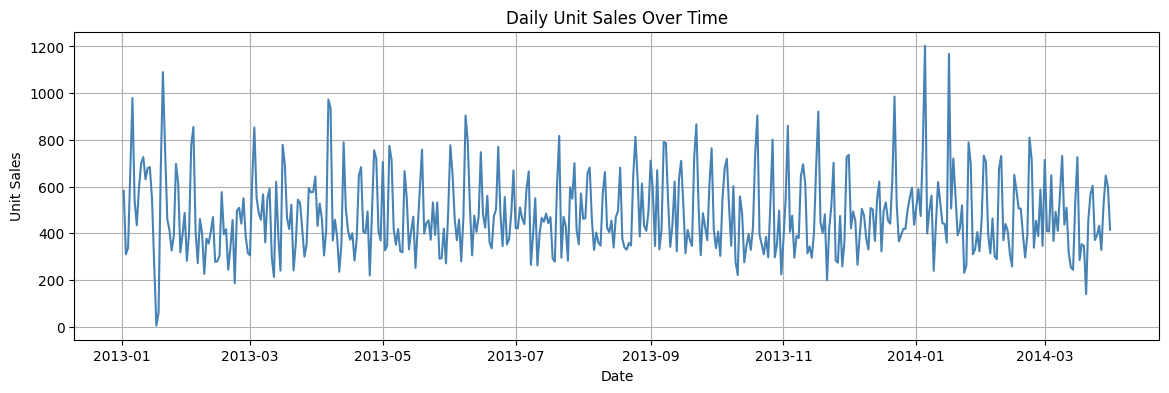

In [78]:
# Plot the sales over time so we can see patterns

timeseries['date'] = pd.to_datetime(timeseries['date'])

plt.figure(figsize=(14, 4))
plt.plot(timeseries['date'], timeseries['unit_sales'], color='steelblue')
plt.title('Daily Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True)
plt.show()

# Look for:
# - Is there an overall trend (going up or down over time)?
# - Are there repeating weekly patterns?
# - Are there unusual spikes (could be holidays)?

---
## Step 5 — Merge the Datasets

Right now we have 4 separate tables. We need to combine them into one table so the model can use all the information together.

**How merging works:**  
Think of it like a VLOOKUP in Excel — we match rows from different tables using a shared column (the date).

In [79]:
# Convert the date column to a proper date format in all tables
# This makes sure dates match correctly when we merge

timeseries['date'] = pd.to_datetime(timeseries['date'])
oil['date']        = pd.to_datetime(oil['date'])
holidays['date']   = pd.to_datetime(holidays['date'])

print("Date columns converted.")

Date columns converted.


In [80]:
# Start with the sales table as our main table
df = timeseries.copy()

# Sort by date from oldest to newest (important for lag features later)
df = df.sort_values('date')
df = df.reset_index(drop=True)

print("Main table ready. Shape:", df.shape)
print(df.head())

Main table ready. Shape: (452, 2)
        date  unit_sales
0 2013-01-02       582.0
1 2013-01-03       310.0
2 2013-01-04       338.0
3 2013-01-05       654.0
4 2013-01-06       979.0


In [81]:
# Merge 1: Add oil prices to our main table
# how='left' means: keep every row from df, and add oil price where the date matches
# If no oil price exists for that date, the value will be blank (NaN) for now

df = df.merge(oil, on='date', how='left')

print("After adding oil prices. Shape:", df.shape)
print(df.head())

After adding oil prices. Shape: (452, 3)
        date  unit_sales  dcoilwtico
0 2013-01-02       582.0       93.14
1 2013-01-03       310.0       92.97
2 2013-01-04       338.0       93.12
3 2013-01-05       654.0         NaN
4 2013-01-06       979.0         NaN


In [82]:
# Merge 2: Add a flag for National Holidays
# First, filter the holidays table to only keep National holidays

national_holidays = holidays[holidays['locale'] == 'National']
national_holidays = national_holidays[['date']].drop_duplicates()
national_holidays['is_national_holiday'] = 1

# Now merge this into our main table
df = df.merge(national_holidays, on='date', how='left')

# Any date that is NOT a national holiday will show NaN — replace with 0
df['is_national_holiday'] = df['is_national_holiday'].fillna(0)
df['is_national_holiday'] = df['is_national_holiday'].astype(int)

print("National holiday flag added.")
print("Number of national holidays in data:", df['is_national_holiday'].sum())

National holiday flag added.
Number of national holidays in data: 22


In [83]:
# Merge 3: Add a flag for Regional Holidays

regional_holidays = holidays[holidays['locale'] == 'Regional']
regional_holidays = regional_holidays[['date']].drop_duplicates()
regional_holidays['is_regional_holiday'] = 1

df = df.merge(regional_holidays, on='date', how='left')
df['is_regional_holiday'] = df['is_regional_holiday'].fillna(0)
df['is_regional_holiday'] = df['is_regional_holiday'].astype(int)

print("Regional holiday flag added.")

Regional holiday flag added.


In [84]:
# Merge 4: Add a flag for Local Holidays

local_holidays = holidays[holidays['locale'] == 'Local']
local_holidays = local_holidays[['date']].drop_duplicates()
local_holidays['is_local_holiday'] = 1

df = df.merge(local_holidays, on='date', how='left')
df['is_local_holiday'] = df['is_local_holiday'].fillna(0)
df['is_local_holiday'] = df['is_local_holiday'].astype(int)

print("Local holiday flag added.")
print()
print("Our merged table now looks like this:")
print(df.head())

Local holiday flag added.

Our merged table now looks like this:
        date  unit_sales  dcoilwtico  is_national_holiday  \
0 2013-01-02       582.0       93.14                    0   
1 2013-01-03       310.0       92.97                    0   
2 2013-01-04       338.0       93.12                    0   
3 2013-01-05       654.0         NaN                    1   
4 2013-01-06       979.0         NaN                    0   

   is_regional_holiday  is_local_holiday  
0                    0                 0  
1                    0                 0  
2                    0                 0  
3                    0                 0  
4                    0                 0  


In [85]:
# Fix missing oil prices
# Some dates have no oil price (e.g. weekends when markets are closed)
# interpolate() fills those gaps by estimating a value between the two nearest prices

df['dcoilwtico'] = df['dcoilwtico'].interpolate('linear')

# Fill any remaining blanks at the very start or end
df['dcoilwtico'] = df['dcoilwtico'].ffill()
df['dcoilwtico'] = df['dcoilwtico'].bfill()

print("Missing oil prices fixed.")
print("Missing values remaining:", df.isnull().sum().sum())

Missing oil prices fixed.
Missing values remaining: 0


### EDA for Merged DataFrame (df)

In [86]:
# Basic info: shape, dtypes, missing values, summary statistics
print("Shape:", df.shape)
print()
print("Column types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print()
print("Summary statistics:")
display(df.describe())

Shape: (452, 6)

Column types:
date                   datetime64[ns]
unit_sales                    float64
dcoilwtico                    float64
is_national_holiday             int64
is_regional_holiday             int64
is_local_holiday                int64
dtype: object

Missing values:
date                   0
unit_sales             0
dcoilwtico             0
is_national_holiday    0
is_regional_holiday    0
is_local_holiday       0
dtype: int64

Date range: 2013-01-02 to 2014-03-31

Summary statistics:


,date,unit_sales,dcoilwtico,is_national_holiday,is_regional_holiday,is_local_holiday
count,452,452.000000,452.000000,452.000000,452.000000,452.000000
mean,2013-08-15 21:46:11.681415936,480.090708,98.137423,0.048673,0.008850,0.053097
min,2013-01-02 00:00:00,4.000000,86.650000,0.000000,0.000000,0.000000
25%,2013-04-24 18:00:00,358.000000,93.960000,0.000000,0.000000,0.000000
50%,2013-08-15 12:00:00,445.500000,96.995000,0.000000,0.000000,0.000000
75%,2013-12-06 06:00:00,578.250000,102.360833,0.000000,0.000000,0.000000
max,2014-03-31 00:00:00,1203.000000,110.620000,1.000000,1.000000,1.000000
std,NaN,170.839776,5.153433,0.215421,0.093759,0.224476


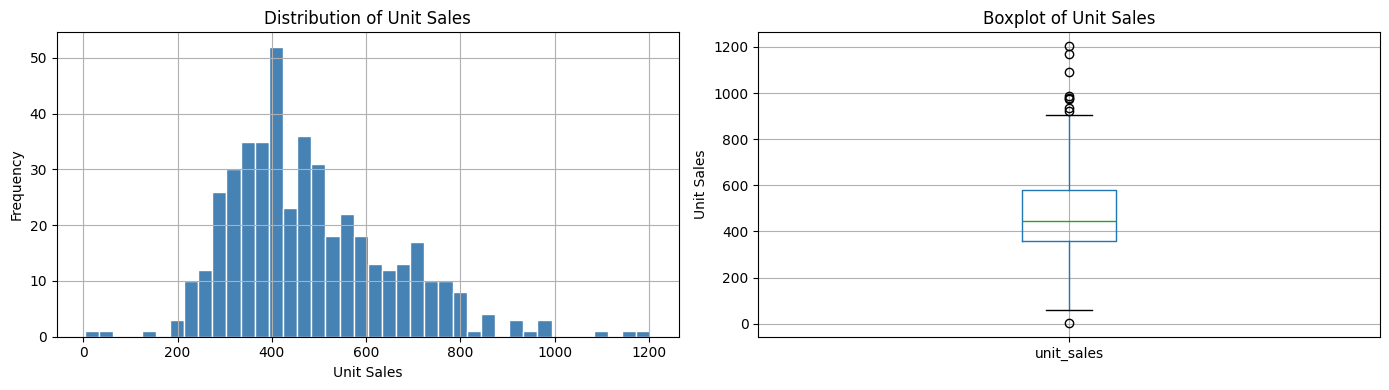

In [87]:
# Unit sales distribution — histogram and boxplot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['unit_sales'].hist(bins=40, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Unit Sales')
axes[0].set_xlabel('Unit Sales')
axes[0].set_ylabel('Frequency')

df.boxplot(column='unit_sales', ax=axes[1])
axes[1].set_title('Boxplot of Unit Sales')
axes[1].set_ylabel('Unit Sales')

plt.tight_layout()
plt.show()

---
## Step 6 — Feature Engineering

**What is feature engineering?**  
Machine learning models learn from numbers, not from raw dates like "2013-01-15".  
We need to extract useful numbers from the date and from past sales.

We will create 5 groups of features:
1. Calendar features — what day, month, weekday is it?
2. Lag features — what were sales in the past?
3. Rolling window features — what is the recent trend?
4. Oil price features — how has oil price changed?
5. Holiday features — already created

### 6a — Calendar Features

In [88]:
# Extract date parts that the model can learn from

# Year (e.g. 2013, 2014)
df['year'] = df['date'].dt.year

# Month number (1 = January, 12 = December)
df['month'] = df['date'].dt.month

# Day of the month (1 to 31)
df['day'] = df['date'].dt.day

# Day of the week (0 = Monday, 6 = Sunday)
df['dayofweek'] = df['date'].dt.dayofweek

# Quarter of the year (1, 2, 3, or 4)
df['quarter'] = df['date'].dt.quarter

# Week number of the year (1 to 52)
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

print("Calendar features added:")
print(df[['date', 'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year']].head(8))

Calendar features added:
        date  year  month  day  dayofweek  quarter  week_of_year
0 2013-01-02  2013      1    2          2        1             1
1 2013-01-03  2013      1    3          3        1             1
2 2013-01-04  2013      1    4          4        1             1
3 2013-01-05  2013      1    5          5        1             1
4 2013-01-06  2013      1    6          6        1             1
5 2013-01-07  2013      1    7          0        1             2
6 2013-01-08  2013      1    8          1        1             2
7 2013-01-09  2013      1    9          2        1             2


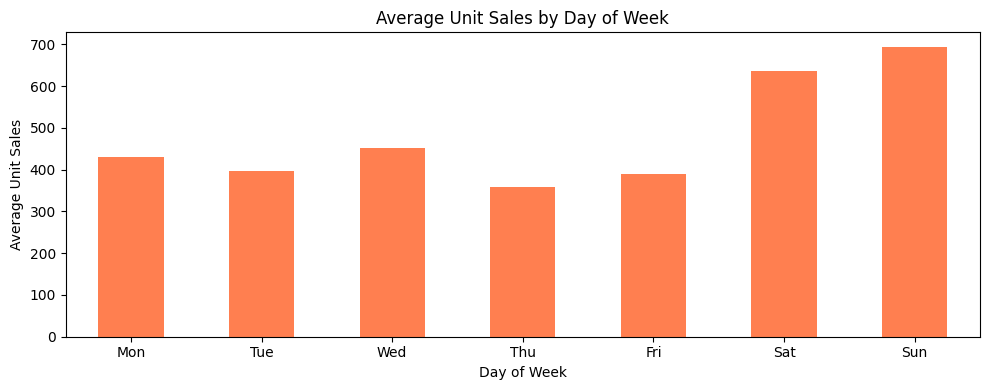

In [89]:
# Average unit sales by day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_by_dow = df.groupby('dayofweek')['unit_sales'].mean()

plt.figure(figsize=(10, 4))
avg_by_dow.plot(kind='bar', color='coral')
plt.title('Average Unit Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Unit Sales')
plt.xticks(ticks=range(7), labels=day_labels, rotation=0)
plt.tight_layout()
plt.show()

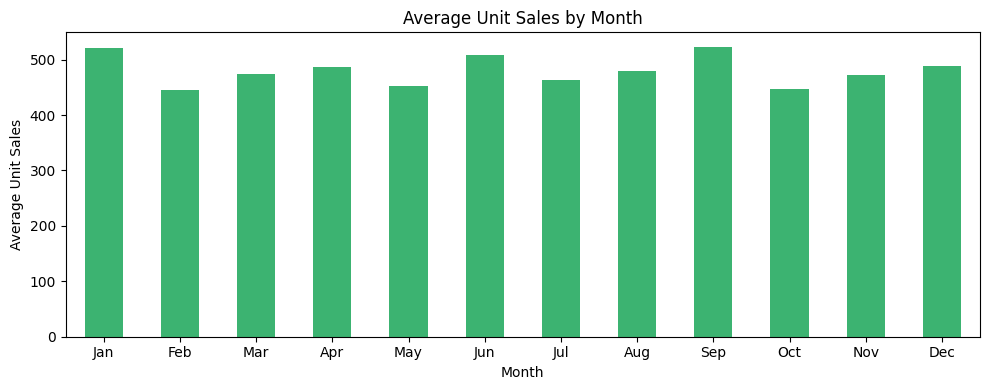

In [90]:
# Average unit sales by month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
avg_by_month = df.groupby('month')['unit_sales'].mean()

plt.figure(figsize=(10, 4))
avg_by_month.plot(kind='bar', color='mediumseagreen')
plt.title('Average Unit Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Unit Sales')
plt.xticks(ticks=range(len(avg_by_month)), labels=[month_labels[m-1] for m in avg_by_month.index], rotation=0)
plt.tight_layout()
plt.show()

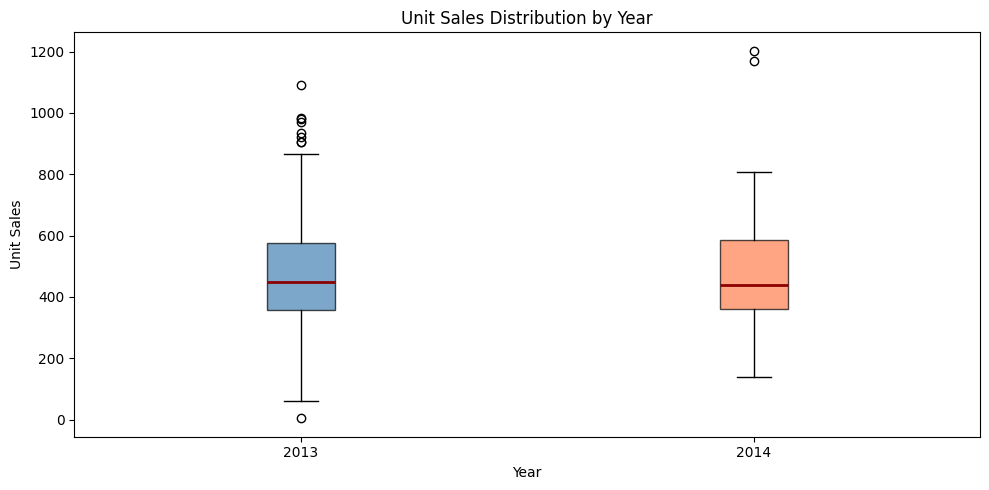

In [91]:
# Unit sales distribution by year (boxplot)
years = sorted(df['year'].unique())
groups = [df[df['year'] == y]['unit_sales'].dropna().values for y in years]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(groups, patch_artist=True)
palette = ['steelblue', 'coral']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('darkred')
    median.set_linewidth(2)
ax.set_xticklabels(years)
ax.set_title('Unit Sales Distribution by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Unit Sales')
plt.tight_layout()
plt.show()

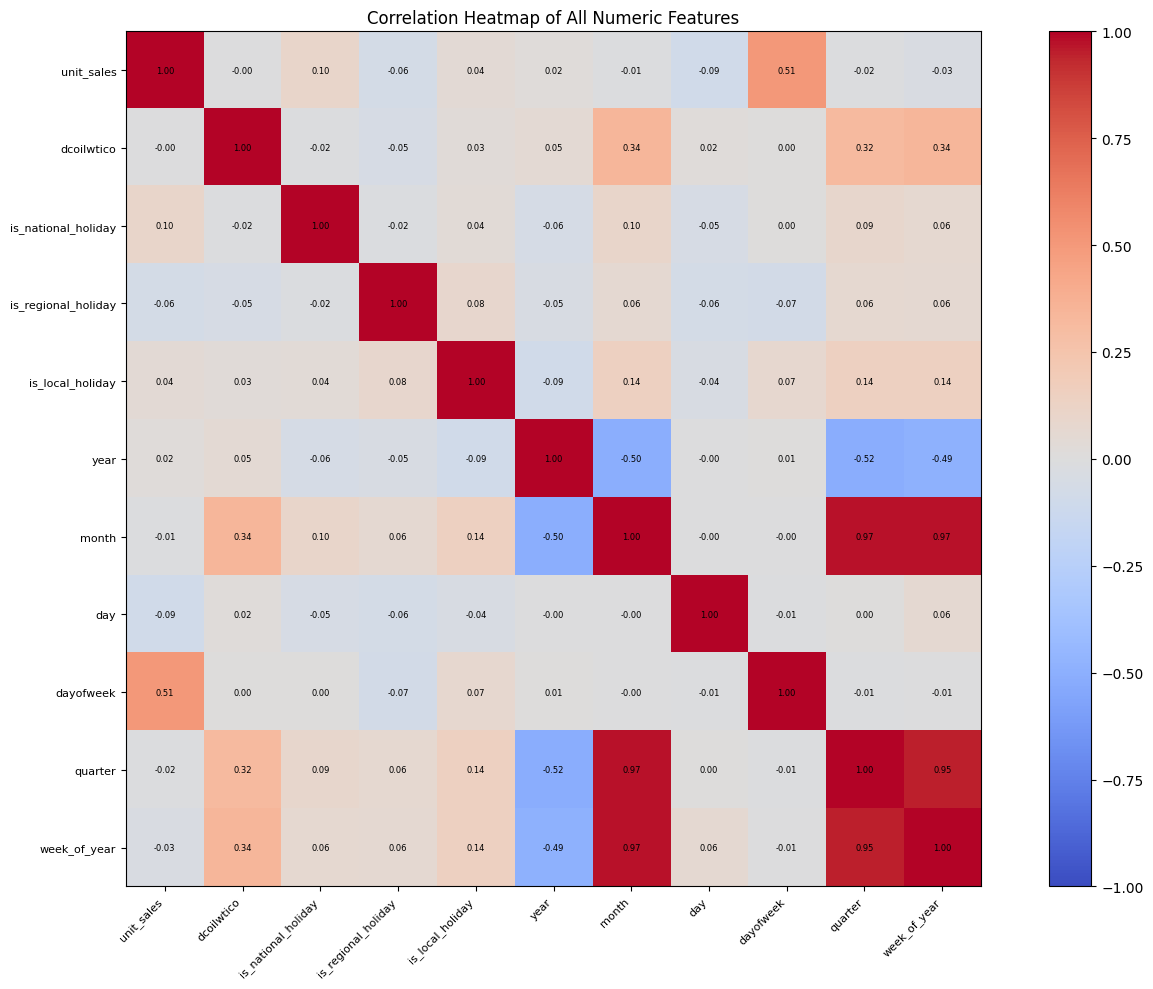

In [92]:
# Correlation heatmap of all numeric features
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
ax.set_title('Correlation Heatmap of All Numeric Features')

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=6)

plt.tight_layout()
plt.show()

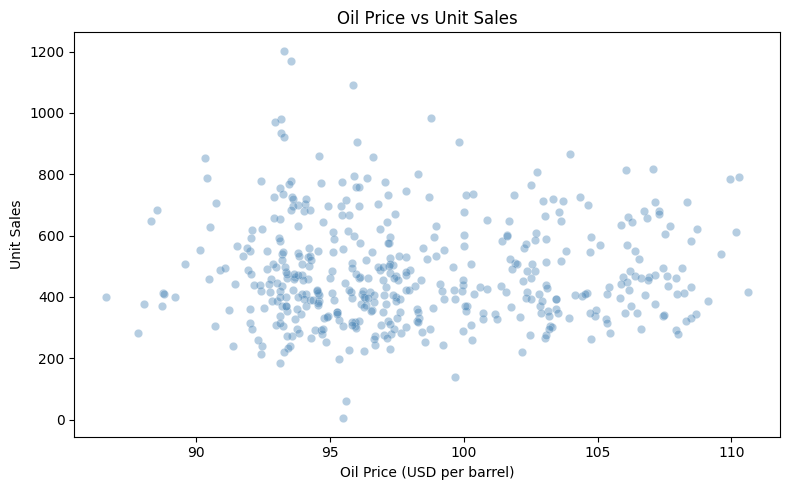

Pearson correlation between oil price and unit sales: -0.001


In [93]:
# Oil price vs unit sales — scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['dcoilwtico'], df['unit_sales'], alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
plt.title('Oil Price vs Unit Sales')
plt.xlabel('Oil Price (USD per barrel)')
plt.ylabel('Unit Sales')
plt.tight_layout()
plt.show()

corr_val = df['dcoilwtico'].corr(df['unit_sales'])
print(f"Pearson correlation between oil price and unit sales: {corr_val:.3f}")

In [94]:
# Create simple yes/no (1 or 0) flags from calendar info

# Is it a weekend? (Saturday = 5, Sunday = 6)
df['is_weekend'] = 0
df.loc[df['dayofweek'] >= 5, 'is_weekend'] = 1

# Is it the first day of the month?
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

# Is it the last day of the month?
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

print("Weekend and month-boundary flags added:")
print(df[['date', 'dayofweek', 'is_weekend', 'is_month_start', 'is_month_end']].head(10))

Weekend and month-boundary flags added:
        date  dayofweek  is_weekend  is_month_start  is_month_end
0 2013-01-02          2           0               0             0
1 2013-01-03          3           0               0             0
2 2013-01-04          4           0               0             0
3 2013-01-05          5           1               0             0
4 2013-01-06          6           1               0             0
5 2013-01-07          0           0               0             0
6 2013-01-08          1           0               0             0
7 2013-01-09          2           0               0             0
8 2013-01-10          3           0               0             0
9 2013-01-11          4           0               0             0


### 6b — Lag Features

A **lag feature** is simply a past value of sales copied into the current row.  
For example, `lag_1` on January 8th will contain the sales from January 7th.

This is useful because yesterday's sales is often the best clue for today's sales.

In [95]:
# lag_1 = sales from 1 day ago (yesterday)
df['lag_1'] = df['unit_sales'].shift(1)

# lag_7 = sales from 7 days ago (same weekday last week)
df['lag_7'] = df['unit_sales'].shift(7)

# lag_14 = sales from 14 days ago (same weekday two weeks ago)
df['lag_14'] = df['unit_sales'].shift(14)

# lag_30 = sales from 30 days ago (roughly same day last month)
df['lag_30'] = df['unit_sales'].shift(30)

print("Lag features added:")
print(df[['date', 'unit_sales', 'lag_1', 'lag_7', 'lag_14', 'lag_30']].head(15))
print()
print("Note: The first rows show NaN because there is no past data for them yet.")

Lag features added:
         date  unit_sales  lag_1  lag_7  lag_14  lag_30
0  2013-01-02       582.0    NaN    NaN     NaN     NaN
1  2013-01-03       310.0  582.0    NaN     NaN     NaN
2  2013-01-04       338.0  310.0    NaN     NaN     NaN
3  2013-01-05       654.0  338.0    NaN     NaN     NaN
4  2013-01-06       979.0  654.0    NaN     NaN     NaN
5  2013-01-07       541.0  979.0    NaN     NaN     NaN
6  2013-01-08       434.0  541.0    NaN     NaN     NaN
7  2013-01-09       593.0  434.0  582.0     NaN     NaN
8  2013-01-10       700.0  593.0  310.0     NaN     NaN
9  2013-01-11       726.0  700.0  338.0     NaN     NaN
10 2013-01-12       631.0  726.0  654.0     NaN     NaN
11 2013-01-13       679.0  631.0  979.0     NaN     NaN
12 2013-01-14       683.0  679.0  541.0     NaN     NaN
13 2013-01-15       547.0  683.0  434.0     NaN     NaN
14 2013-01-16       265.0  547.0  593.0   582.0     NaN

Note: The first rows show NaN because there is no past data for them yet.


### 6c — Rolling Window Features

A **rolling average** is the average of the last N days of sales.  
It smooths out day-to-day ups and downs so the model can see the overall trend.

Example: the 7-day rolling average on day 10 = average of days 3 through 9.

In [96]:
# We shift by 1 first to make sure we only use PAST data
# (we never want to accidentally include today's sales when predicting today)
past_sales = df['unit_sales'].shift(1)

# Average sales over the last 7 days
df['rolling_7d_mean'] = past_sales.rolling(window=7).mean()

# Average sales over the last 14 days
df['rolling_14d_mean'] = past_sales.rolling(window=14).mean()

# Average sales over the last 30 days
df['rolling_30d_mean'] = past_sales.rolling(window=30).mean()

# Standard deviation over the last 7 days
# This measures how much sales varied — high std means unpredictable sales
df['rolling_7d_std'] = past_sales.rolling(window=7).std()

print("Rolling window features added:")
print(df[['date', 'unit_sales', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_7d_std']].head(20))

Rolling window features added:
         date  unit_sales  rolling_7d_mean  rolling_14d_mean  rolling_7d_std
0  2013-01-02       582.0              NaN               NaN             NaN
1  2013-01-03       310.0              NaN               NaN             NaN
2  2013-01-04       338.0              NaN               NaN             NaN
3  2013-01-05       654.0              NaN               NaN             NaN
4  2013-01-06       979.0              NaN               NaN             NaN
5  2013-01-07       541.0              NaN               NaN             NaN
6  2013-01-08       434.0              NaN               NaN             NaN
7  2013-01-09       593.0       548.285714               NaN      228.013680
8  2013-01-10       700.0       549.857143               NaN      228.322454
9  2013-01-11       726.0       605.571429               NaN      206.587235
10 2013-01-12       631.0       661.000000               NaN      171.984495
11 2013-01-13       679.0       657.714286   

### 6d — Oil Price Features

Ecuador depends heavily on oil revenue. When oil prices drop, the economy is affected and people tend to spend less.  
We use the **previous day's** oil price (not today's) because economic effects take time.

In [97]:
# Oil price from yesterday
df['oil_lag_1'] = df['dcoilwtico'].shift(1)

# Average oil price over the last 7 days (smoothed trend)
df['oil_rolling_7d_mean'] = df['dcoilwtico'].shift(1).rolling(window=7).mean()

print("Oil price features added:")
print(df[['date', 'dcoilwtico', 'oil_lag_1', 'oil_rolling_7d_mean']].head(15))

Oil price features added:
         date  dcoilwtico  oil_lag_1  oil_rolling_7d_mean
0  2013-01-02   93.140000        NaN                  NaN
1  2013-01-03   92.970000  93.140000                  NaN
2  2013-01-04   93.120000  92.970000                  NaN
3  2013-01-05   93.146667  93.120000                  NaN
4  2013-01-06   93.173333  93.146667                  NaN
5  2013-01-07   93.200000  93.173333                  NaN
6  2013-01-08   93.210000  93.200000                  NaN
7  2013-01-09   93.080000  93.210000            93.137143
8  2013-01-10   93.810000  93.080000            93.128571
9  2013-01-11   93.600000  93.810000            93.248571
10 2013-01-12   93.823333  93.600000            93.317143
11 2013-01-13   94.046667  93.823333            93.413810
12 2013-01-14   94.270000  94.046667            93.538571
13 2013-01-15   93.260000  94.270000            93.691429
14 2013-01-16   94.280000  93.260000            93.698571


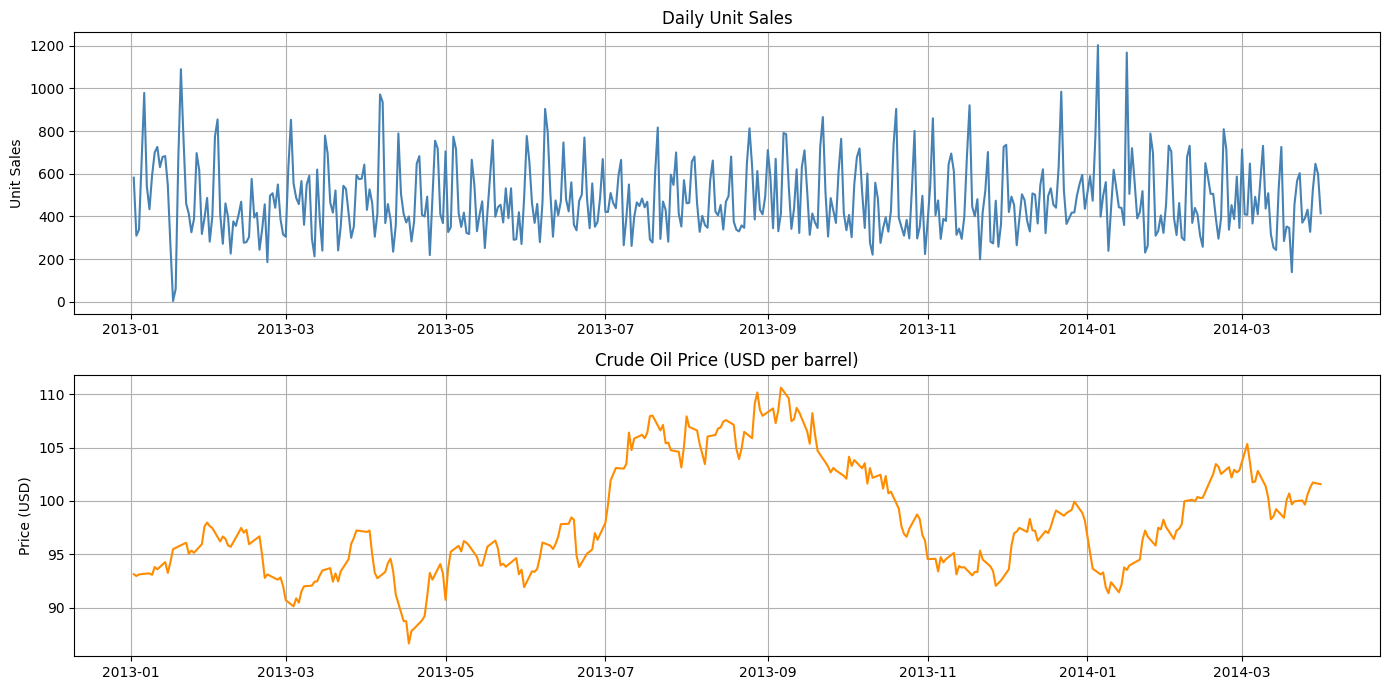

In [98]:
# Visualise oil price vs unit sales side by side

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df['date'], df['unit_sales'], color='steelblue')
axes[0].set_title('Daily Unit Sales')
axes[0].set_ylabel('Unit Sales')
axes[0].grid(True)

axes[1].plot(df['date'], df['dcoilwtico'], color='darkorange')
axes[1].set_title('Crude Oil Price (USD per barrel)')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 6e — Holiday Features (visualise them)

In [99]:
# Compare average sales on holiday vs non-holiday days

avg_sales_holiday     = df[df['is_national_holiday'] == 1]['unit_sales'].mean()
avg_sales_no_holiday  = df[df['is_national_holiday'] == 0]['unit_sales'].mean()

print("Average sales on National Holiday days: ", round(avg_sales_holiday, 1))
print("Average sales on non-holiday days:      ", round(avg_sales_no_holiday, 1))

Average sales on National Holiday days:  556.2
Average sales on non-holiday days:       476.2


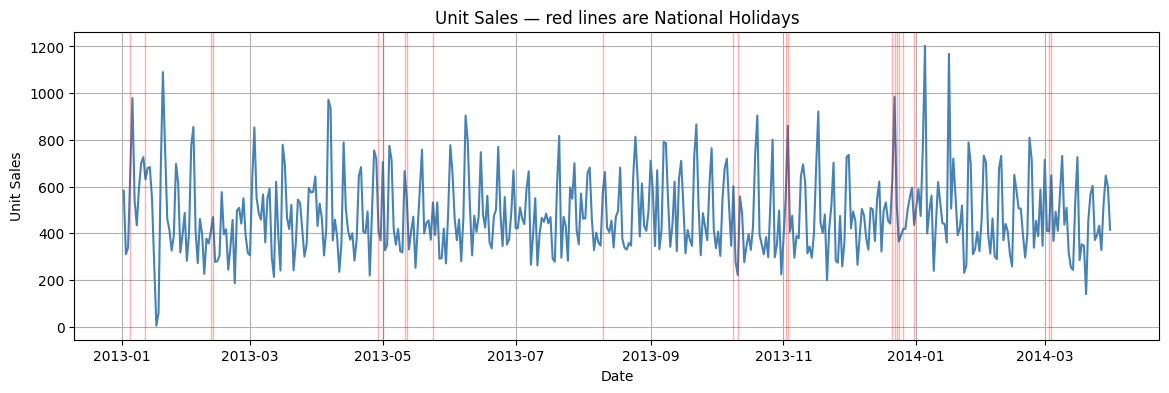

In [100]:
# Plot sales and highlight national holiday dates with a red line

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['unit_sales'], color='steelblue', label='Unit Sales')

# Draw a vertical red line for every national holiday
holiday_dates = df[df['is_national_holiday'] == 1]['date']
for holiday_date in holiday_dates:
    plt.axvline(x=holiday_date, color='red', alpha=0.3, linewidth=1)

plt.title('Unit Sales — red lines are National Holidays')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True)
plt.show()

In [101]:
print(df)

          date  unit_sales  dcoilwtico  is_national_holiday  \
0   2013-01-02       582.0   93.140000                    0   
1   2013-01-03       310.0   92.970000                    0   
2   2013-01-04       338.0   93.120000                    0   
3   2013-01-05       654.0   93.146667                    1   
4   2013-01-06       979.0   93.173333                    0   
..         ...         ...         ...                  ...   
447 2014-03-27       328.0  101.250000                    0   
448 2014-03-28       523.0  101.730000                    0   
449 2014-03-29       647.0  101.676667                    0   
450 2014-03-30       599.0  101.623333                    0   
451 2014-03-31       415.0  101.570000                    0   

     is_regional_holiday  is_local_holiday  year  month  day  dayofweek  ...  \
0                      0                 0  2013      1    2          2  ...   
1                      0                 0  2013      1    3          3  ...   
2  

---
## Final EDA — Fully Engineered DataFrame

At this point `df` contains all 25 columns: the target variable (`unit_sales`), oil price, holiday flags, calendar features, lag features, and rolling window features.

The cells below explore each group of features in depth.

In [102]:
# Overview: shape, dtypes, missing values, summary statistics
print("Shape:", df.shape)
print()
print("Column types:")
print(df.dtypes)
print()
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Total rows:", len(df), " | Total features:", df.shape[1] - 1)
print()
print("Summary statistics:")
display(df.describe().round(2))

Shape: (452, 25)

Column types:
date                   datetime64[ns]
unit_sales                    float64
dcoilwtico                    float64
is_national_holiday             int64
is_regional_holiday             int64
is_local_holiday                int64
year                            int32
month                           int32
day                             int32
dayofweek                       int32
quarter                         int32
week_of_year                    int64
is_weekend                      int64
is_month_start                  int64
is_month_end                    int64
lag_1                         float64
lag_7                         float64
lag_14                        float64
lag_30                        float64
rolling_7d_mean               float64
rolling_14d_mean              float64
rolling_30d_mean              float64
rolling_7d_std                float64
oil_lag_1                     float64
oil_rolling_7d_mean           float64
dtype: object

Dat

,date,unit_sales,dcoilwtico,is_national_holiday,is_regional_holiday,is_local_holiday,year,month,day,dayofweek,...,lag_1,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_rolling_7d_mean
count,452,452.00,452.00,452.00,452.00,452.00,452.0,452.00,452.00,452.00,...,451.00,445.00,438.00,422.00,445.00,438.00,422.00,445.00,451.00,445.00
mean,2013-08-15 21:46:11.681415936,480.09,98.14,0.05,0.01,0.05,2013.2,5.64,15.73,3.01,...,480.24,480.15,481.35,482.19,479.64,478.90,478.82,166.58,98.13,98.14
min,2013-01-02 00:00:00,4.00,86.65,0.00,0.00,0.00,2013.0,1.00,1.00,0.00,...,4.00,4.00,4.00,4.00,341.71,361.71,405.67,63.79,86.65,88.12
25%,2013-04-24 18:00:00,358.00,93.96,0.00,0.00,0.00,2013.0,2.00,8.00,1.00,...,358.00,358.00,358.50,358.50,448.00,454.18,463.71,127.65,93.96,94.19
50%,2013-08-15 12:00:00,445.50,97.00,0.00,0.00,0.00,2013.0,5.00,16.00,3.00,...,447.00,447.00,448.00,451.00,478.14,475.25,475.42,162.70,96.99,96.79
75%,2013-12-06 06:00:00,578.25,102.36,0.00,0.00,0.00,2013.0,9.00,23.00,5.00,...,579.50,577.00,580.75,582.75,506.86,502.82,492.23,196.25,102.36,102.59
max,2014-03-31 00:00:00,1203.00,110.62,1.00,1.00,1.00,2014.0,12.00,31.00,6.00,...,1203.00,1203.00,1203.00,1203.00,661.00,603.93,561.20,395.60,110.62,109.28
std,NaN,170.84,5.15,0.22,0.09,0.22,0.4,3.59,8.75,2.01,...,171.00,171.65,171.78,172.51,53.75,38.63,27.50,54.28,5.16,5.07


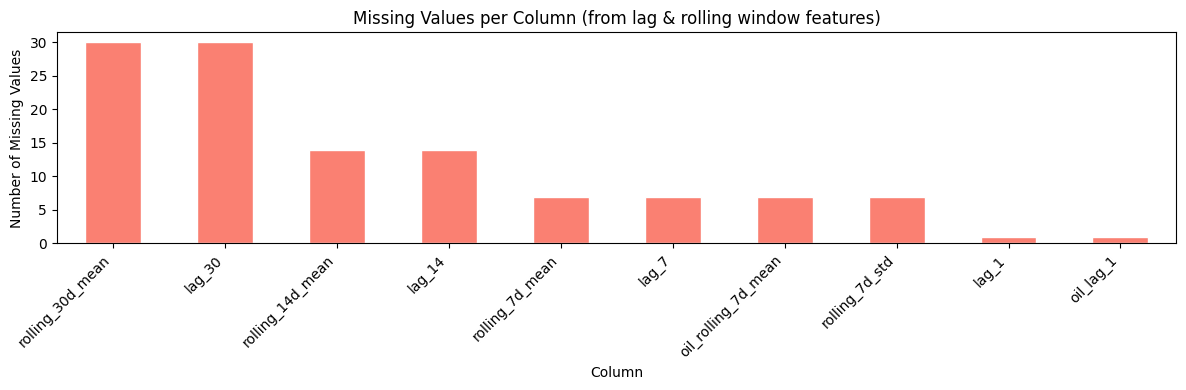

Columns with missing values:
rolling_30d_mean       30
lag_30                 30
rolling_14d_mean       14
lag_14                 14
rolling_7d_mean         7
lag_7                   7
oil_rolling_7d_mean     7
rolling_7d_std          7
lag_1                   1
oil_lag_1               1


In [103]:
# Missing values per column (lag/rolling produce NaNs by design)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 4))
missing.plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Missing Values per Column (from lag & rolling window features)')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Columns with missing values:")
print(missing.to_string())

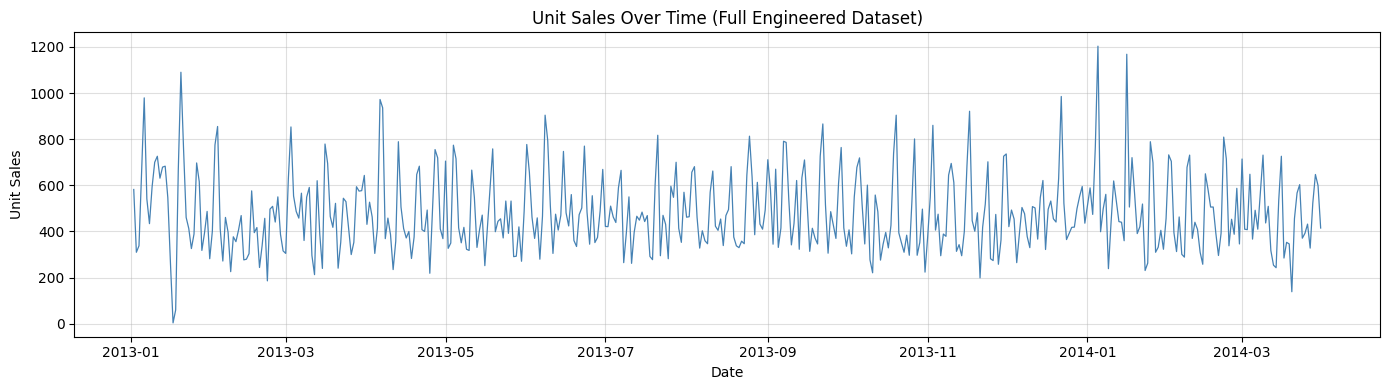

In [104]:
# Unit sales over time — full date range
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['unit_sales'], color='steelblue', linewidth=0.9)
plt.title('Unit Sales Over Time (Full Engineered Dataset)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

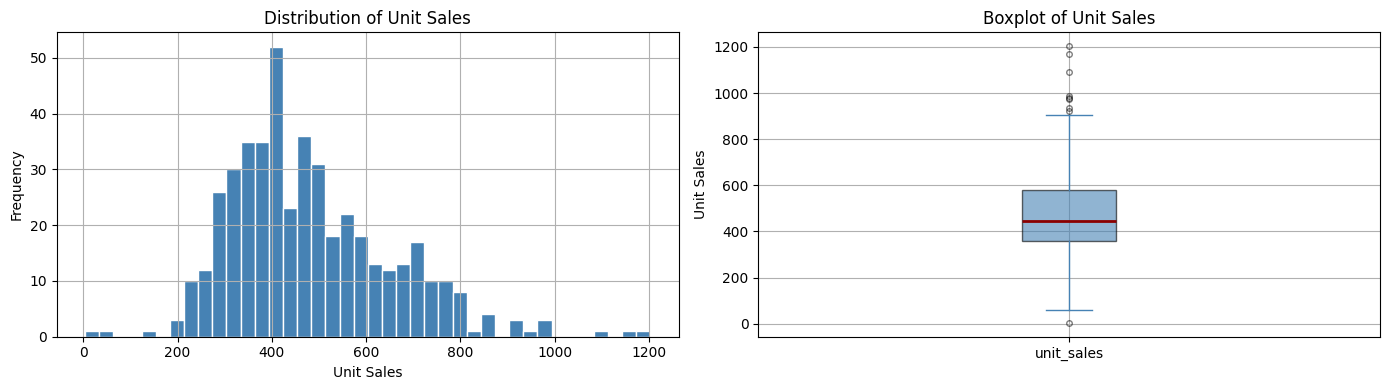

Mean:   480.1
Median: 445.5
Std:    170.8
Min:    4.0  |  Max: 1203.0


In [105]:
# Unit sales distribution — histogram and boxplot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['unit_sales'].hist(bins=40, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Unit Sales')
axes[0].set_xlabel('Unit Sales')
axes[0].set_ylabel('Frequency')

df.boxplot(column='unit_sales', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='darkred', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'),
           flierprops=dict(marker='o', color='steelblue', alpha=0.5, markersize=4))
axes[1].set_title('Boxplot of Unit Sales')
axes[1].set_ylabel('Unit Sales')

plt.tight_layout()
plt.show()

print(f"Mean:   {df['unit_sales'].mean():.1f}")
print(f"Median: {df['unit_sales'].median():.1f}")
print(f"Std:    {df['unit_sales'].std():.1f}")
print(f"Min:    {df['unit_sales'].min():.1f}  |  Max: {df['unit_sales'].max():.1f}")

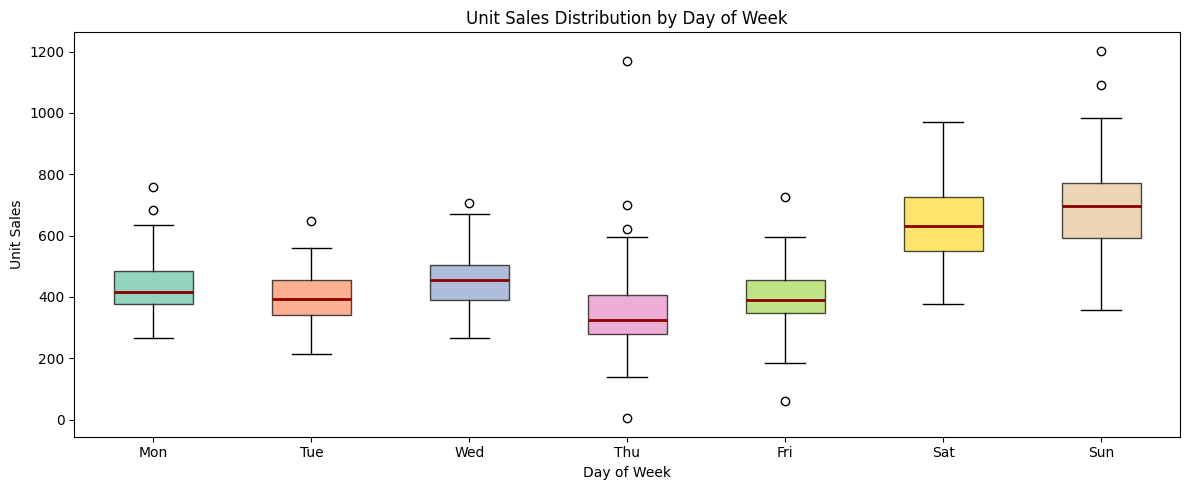

In [106]:
# Unit sales boxplot by day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
groups = [df[df['dayofweek'] == d]['unit_sales'].dropna().values for d in range(7)]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(groups, patch_artist=True)
palette = plt.cm.Set2.colors[:7]
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('darkred')
    median.set_linewidth(2)
ax.set_xticklabels(day_labels)
ax.set_title('Unit Sales Distribution by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Unit Sales')
plt.tight_layout()
plt.show()

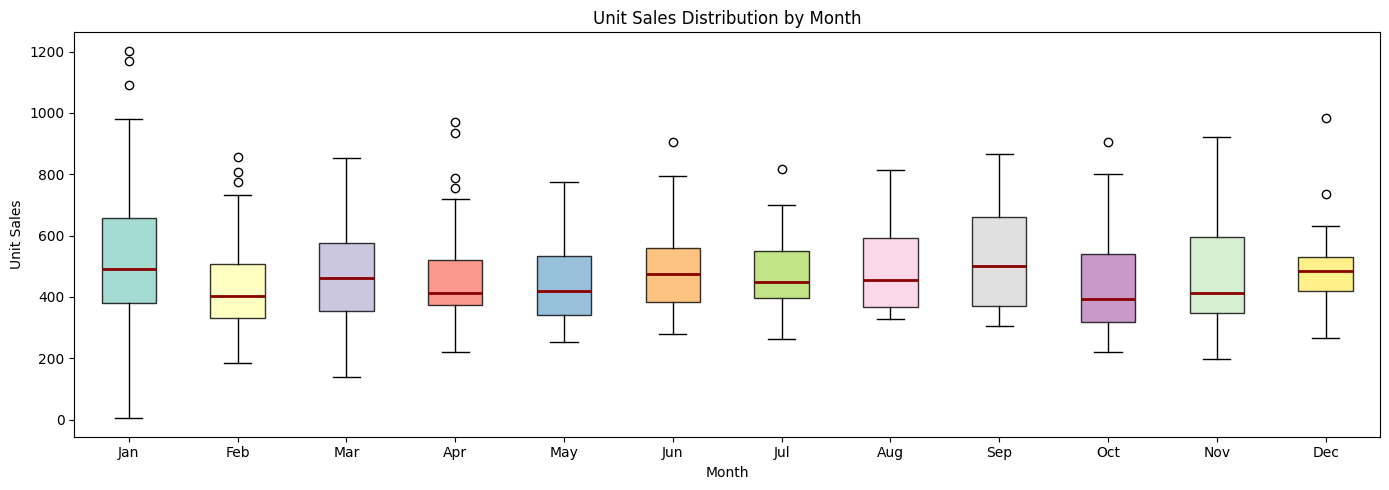

In [107]:
# Unit sales boxplot by month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
present_months = sorted(df['month'].unique())
groups = [df[df['month'] == m]['unit_sales'].dropna().values for m in present_months]
labels = [month_labels[m-1] for m in present_months]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(groups, patch_artist=True)
palette = plt.cm.Set3.colors[:len(present_months)]
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for median in bp['medians']:
    median.set_color('darkred')
    median.set_linewidth(2)
ax.set_xticklabels(labels)
ax.set_title('Unit Sales Distribution by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Unit Sales')
plt.tight_layout()
plt.show()

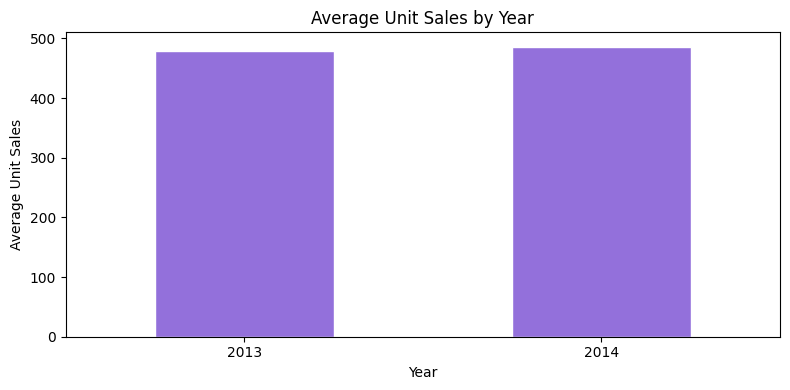

In [108]:
# Average unit sales by year
avg_by_year = df.groupby('year')['unit_sales'].mean()

plt.figure(figsize=(8, 4))
avg_by_year.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Average Unit Sales by Year')
plt.xlabel('Year')
plt.ylabel('Average Unit Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

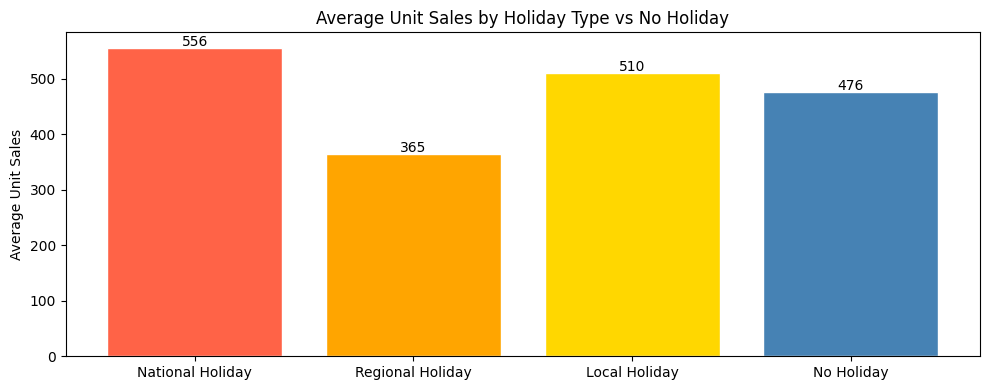

In [109]:
# Average unit sales by holiday type vs no-holiday days
no_hol_avg  = df[(df['is_national_holiday']==0) & (df['is_regional_holiday']==0) & (df['is_local_holiday']==0)]['unit_sales'].mean()
nat_avg      = df[df['is_national_holiday']==1]['unit_sales'].mean()
reg_avg      = df[df['is_regional_holiday']==1]['unit_sales'].mean()
loc_avg      = df[df['is_local_holiday']==1]['unit_sales'].mean()

labels = ['National Holiday', 'Regional Holiday', 'Local Holiday', 'No Holiday']
values = [nat_avg, reg_avg, loc_avg, no_hol_avg]
bar_colors = ['tomato', 'orange', 'gold', 'steelblue']

plt.figure(figsize=(10, 4))
bars = plt.bar(labels, values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4, f'{val:.0f}', ha='center', fontsize=10)
plt.title('Average Unit Sales by Holiday Type vs No Holiday')
plt.ylabel('Average Unit Sales')
plt.tight_layout()
plt.show()

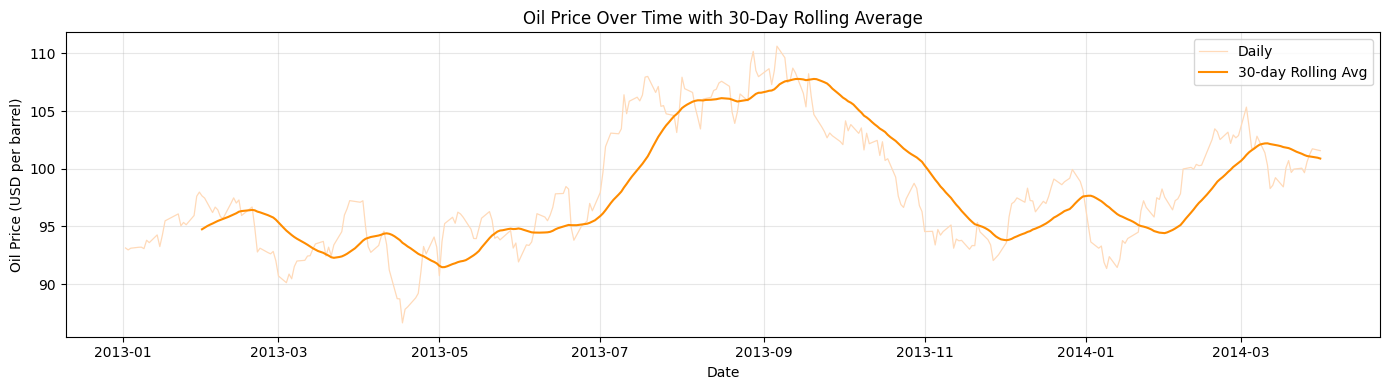

In [110]:
# Oil price over time with 30-day rolling average
df_s = df.sort_values('date')
plt.figure(figsize=(14, 4))
plt.plot(df_s['date'], df_s['dcoilwtico'], color='peachpuff', linewidth=0.9, label='Daily')
plt.plot(df_s['date'], df_s['dcoilwtico'].rolling(30).mean(), color='darkorange', linewidth=1.5, label='30-day Rolling Avg')
plt.title('Oil Price Over Time with 30-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Oil Price (USD per barrel)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

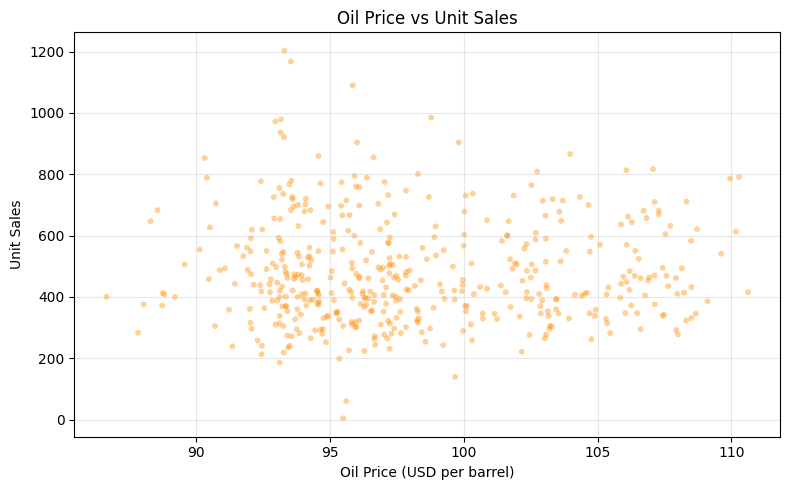

Pearson correlation (oil price vs unit_sales): -0.001


In [111]:
# Oil price vs unit sales scatter with Pearson correlation
plt.figure(figsize=(8, 5))
plt.scatter(df['dcoilwtico'], df['unit_sales'], alpha=0.4, color='darkorange', edgecolors='none', s=18)
plt.title('Oil Price vs Unit Sales')
plt.xlabel('Oil Price (USD per barrel)')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson correlation (oil price vs unit_sales): {df['dcoilwtico'].corr(df['unit_sales']):.3f}")

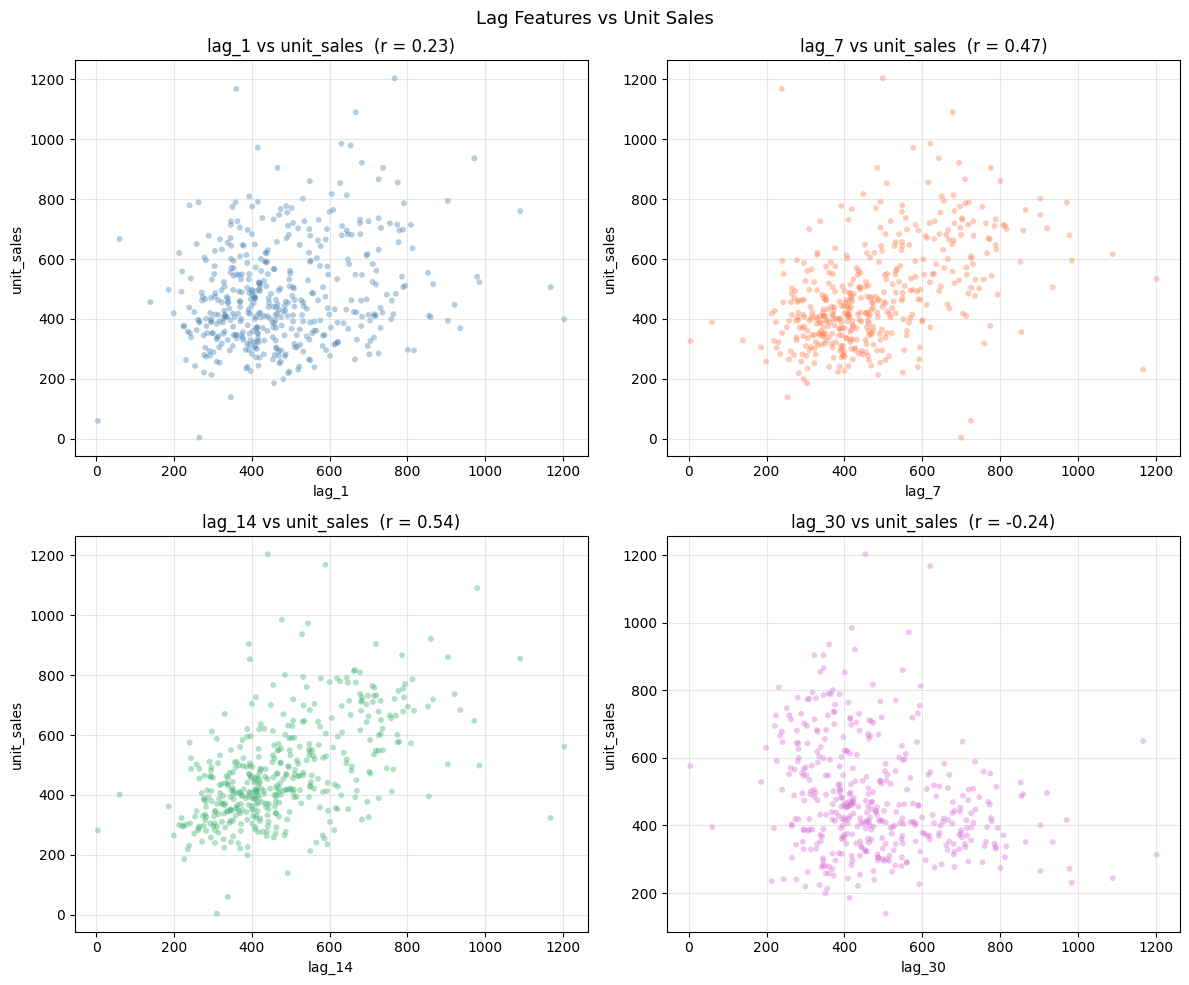

In [112]:
# Lag features vs unit_sales — 2x2 scatter subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
lag_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_30']
colors   = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

for ax, col, color in zip(axes.flat, lag_cols, colors):
    valid = df[['unit_sales', col]].dropna()
    ax.scatter(valid[col], valid['unit_sales'], alpha=0.4, color=color, edgecolors='none', s=18)
    r = valid[col].corr(valid['unit_sales'])
    ax.set_title(f'{col} vs unit_sales  (r = {r:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('unit_sales')
    ax.grid(True, alpha=0.3)

plt.suptitle('Lag Features vs Unit Sales', fontsize=13)
plt.tight_layout()
plt.show()

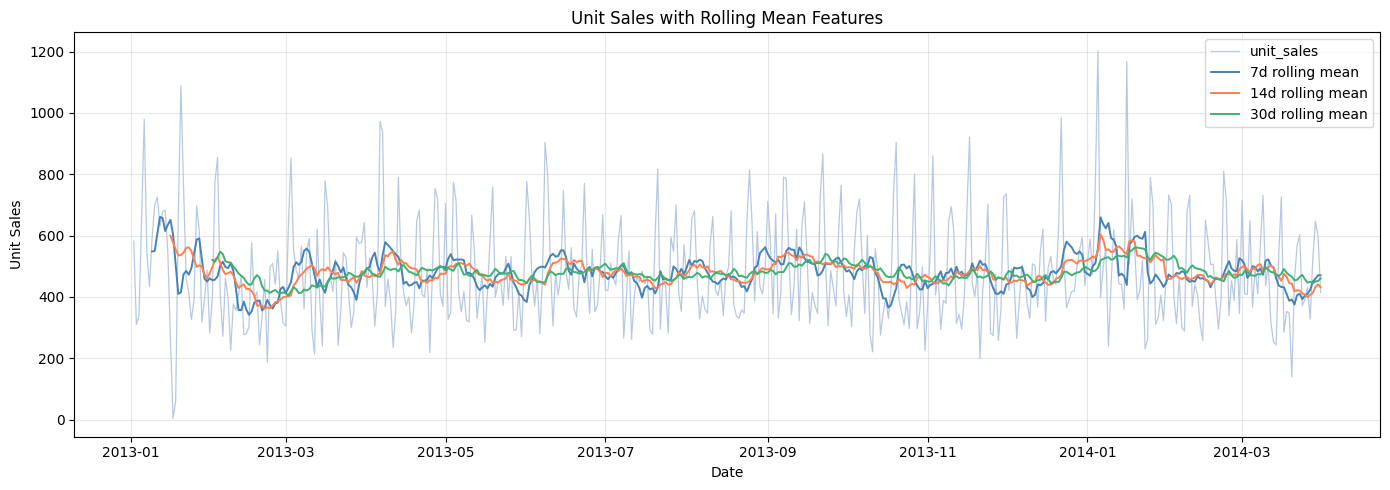

In [113]:
# Rolling mean features overlaid on unit sales
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['unit_sales'], color='lightsteelblue', linewidth=0.9, alpha=0.9, label='unit_sales')
plt.plot(df['date'], df['rolling_7d_mean'],  color='steelblue',      linewidth=1.4, label='7d rolling mean')
plt.plot(df['date'], df['rolling_14d_mean'], color='coral',          linewidth=1.4, label='14d rolling mean')
plt.plot(df['date'], df['rolling_30d_mean'], color='mediumseagreen',  linewidth=1.4, label='30d rolling mean')
plt.title('Unit Sales with Rolling Mean Features')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

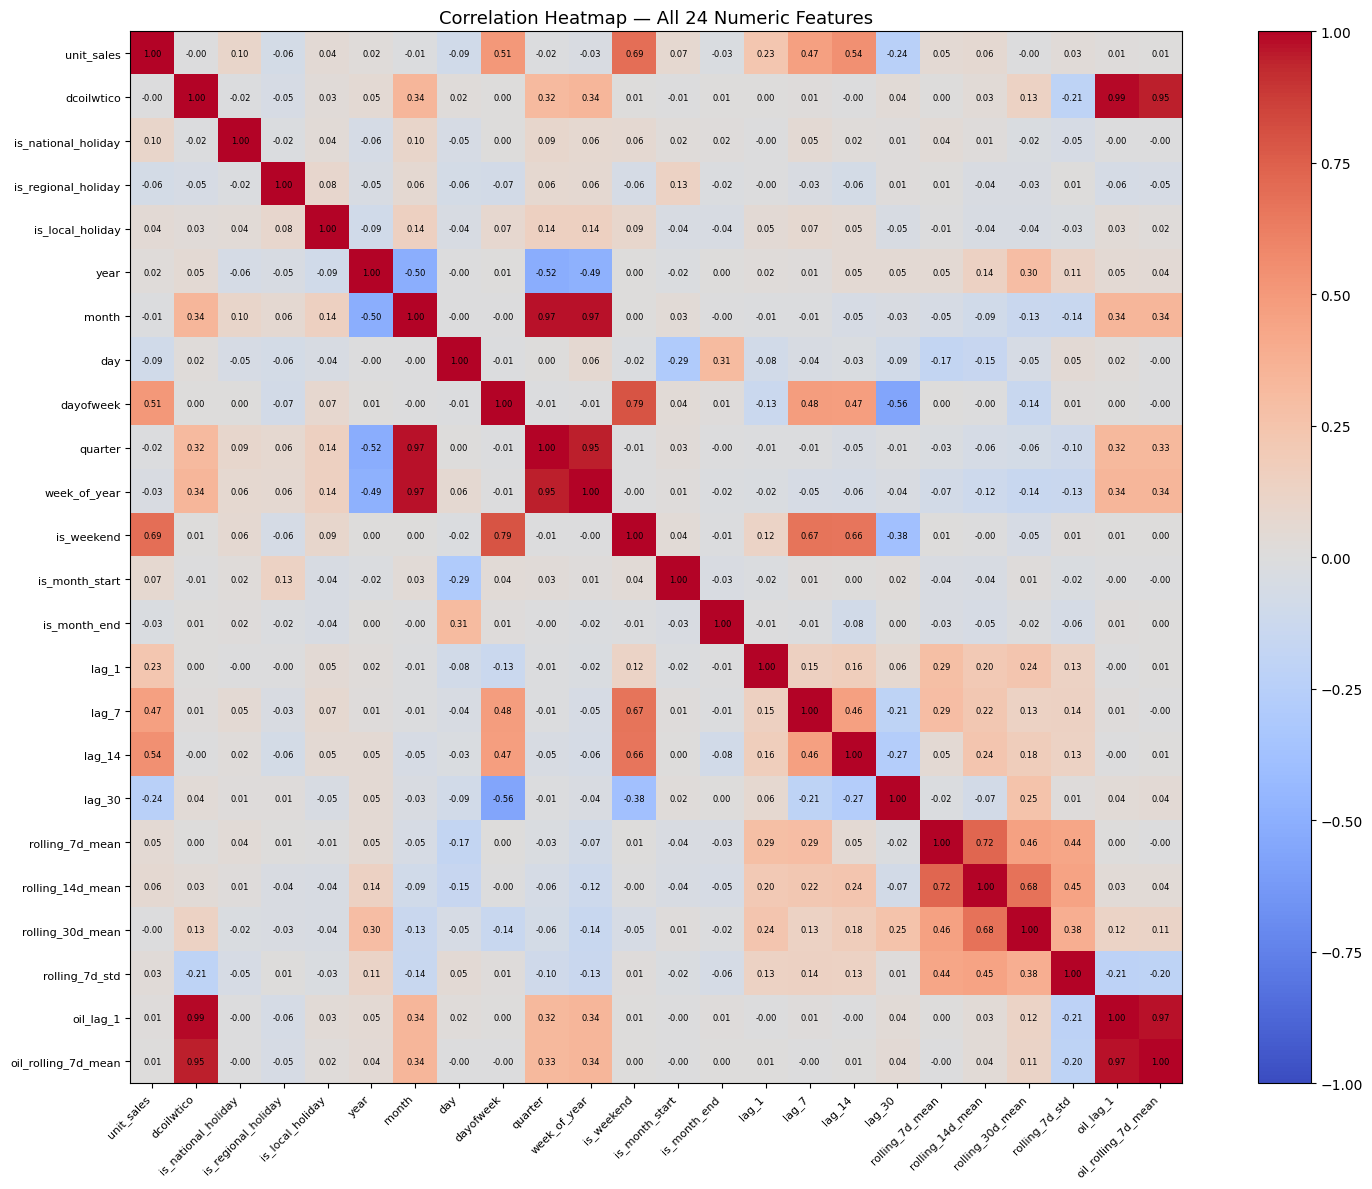

In [114]:
# Full correlation heatmap of all numeric features
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
ax.set_title('Correlation Heatmap — All 24 Numeric Features', fontsize=13)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=6)

plt.tight_layout()
plt.show()

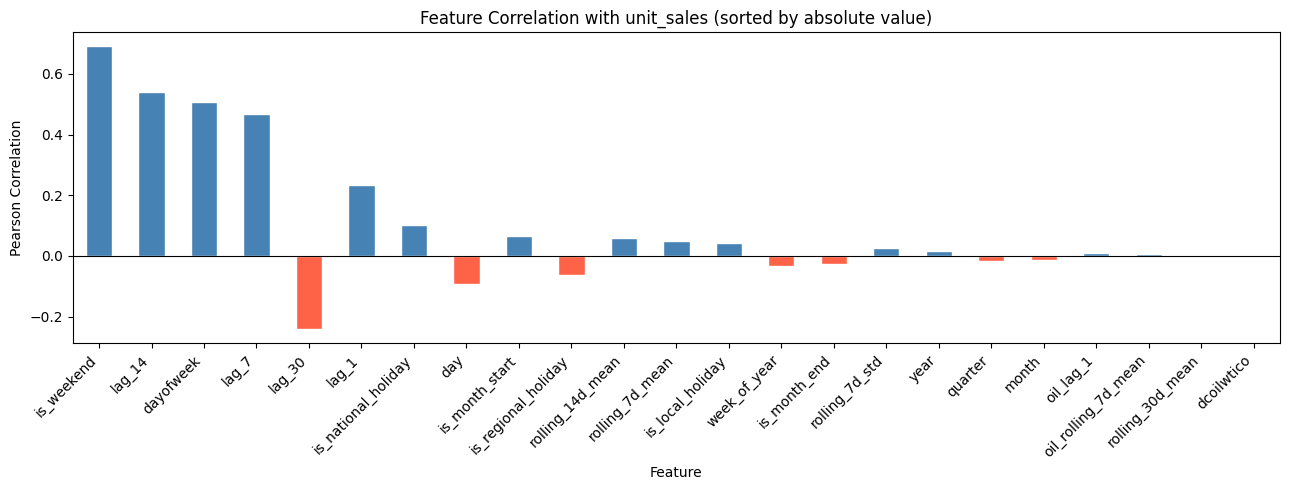

Top 5 positively correlated:
is_weekend    0.690
lag_14        0.539
dayofweek     0.507
lag_7         0.466
lag_1         0.233

Top 5 negatively correlated:
lag_30                -0.242
day                   -0.093
is_regional_holiday   -0.064
week_of_year          -0.032
is_month_end          -0.026


In [115]:
# Top features correlated with unit_sales (bar chart)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_with_target = (
    df[numeric_cols].corr()['unit_sales']
    .drop('unit_sales')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(13, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_with_target.values]
corr_with_target.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Feature Correlation with unit_sales (sorted by absolute value)')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 positively correlated:")
print(corr_with_target[corr_with_target > 0].head(5).round(3).to_string())
print("\nTop 5 negatively correlated:")
print(corr_with_target[corr_with_target < 0].head(5).round(3).to_string())